<a href="https://colab.research.google.com/github/Saiful-2/forest-cover-classification/blob/main/notebooks/3%264_forest_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## STEP 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

<Figure size 800x500 with 0 Axes>

## Step 2: Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/Saiful-2/datasets/main/forest_cleaned_dataset.csv"
df = pd.read_csv(url)

df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type,Soil_Sum
0,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,0,0,1,0,0,1,1
1,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,0,2,1
2,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,0,2,1
3,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,2,1
4,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,2,1


## 🟢 STEP 3: Prepare Data

In [3]:
from sklearn.model_selection import train_test_split
# Create Features (X)
X = df.drop('Cover_Type', axis=1)
# Create Target (y)
y = df['Cover_Type']
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 🟢 STEP 4: Feature Scaling (IMPORTANT for KNN & Logistic)

In [4]:
#Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create Scaler Object
scaler = StandardScaler()

# Fit + Transform Training Data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🟢 STEP 5: Train Models
## ✅ 1. Logistic Regression

In [5]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

## ✅ 2. Decision Tree

In [6]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

## ✅ 3. Random Forest

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## ✅ 4. KNN

In [8]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

# 🟢 STEP 5: Model Evaluation

In [9]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("KNN:", accuracy_score(y_test, y_pred_knn))

Logistic Regression: 0.7275110085971902
Decision Tree: 0.8149507234221011
Random Forest: 0.7997483749213672
KNN: 0.8253302579157056


# 🟢 STEP 6: Detailed Evaluation

In [10]:
from sklearn.metrics import classification_report

print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Report:
               precision    recall  f1-score   support

           1       0.80      0.77      0.78      3662
           2       0.79      0.87      0.83      4742
           3       0.84      0.81      0.83       422
           4       1.00      0.38      0.55         8
           5       0.95      0.14      0.25       148
           6       0.83      0.44      0.58       229
           7       0.95      0.65      0.77       327

    accuracy                           0.80      9538
   macro avg       0.88      0.58      0.65      9538
weighted avg       0.80      0.80      0.79      9538



# 🟢 STEP 7: Compare Models

In [11]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "KNN": accuracy_score(y_test, y_pred_knn)
}

results

{'Logistic Regression': 0.7275110085971902,
 'Decision Tree': 0.8149507234221011,
 'Random Forest': 0.7997483749213672,
 'KNN': 0.8253302579157056}

# 🟢 STEP 8: Visualization of Results

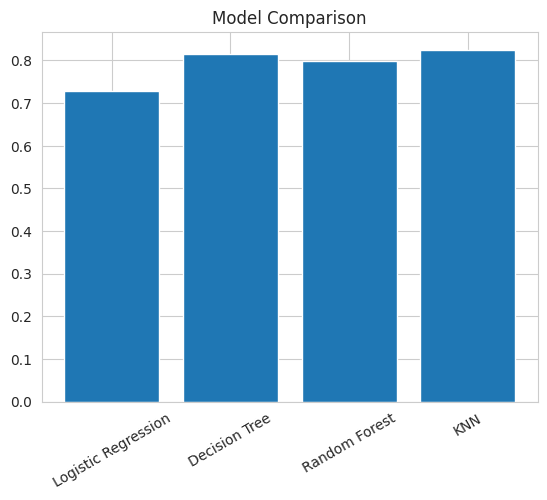

In [12]:
import matplotlib.pyplot as plt

models = list(results.keys())
scores = list(results.values())

plt.bar(models, scores)
plt.title("Model Comparison")
plt.xticks(rotation=30)
plt.show()

## FINAL INSIGHTS

Example (adapt based on your output):

Random Forest achieved highest accuracy → best model
Logistic Regression performed lower → data not linearly separable
Decision Tree may overfit
KNN performance depends on scaling